# A Nonlinear Neural Transport Example

We now use a genuinely nonlinear transport map
$$
P_\theta = (T_\theta)_\# \rho, \qquad \rho = \mathrm{Unif}[-1,1],
$$
where $T_\theta$ is a two-layer network with two hidden neurons. To obtain a literal two-dimensional landscape while still using learnable features, we let the two trainable parameters control the hidden-unit locations
$$
\theta = (\theta_1,\theta_2),
$$
with
$$
T_\theta(z) = 0.35 z + 0.9\, \tanh\!\bigl(3.2(z-\theta_1)\bigr) - 0.9\, \tanh\!\bigl(3.2(z-\theta_2)\bigr).
$$

The target is the symmetric two-mode Gaussian mixture
$$
Q = \tfrac12\, \mathcal N(-a,\tau^2) + \tfrac12\, \mathcal N(a,\tau^2).
$$

## Standard GD vs Adaptive Projected GD

Because the transport is nonlinear, the parametric MMD landscape in $(\theta_1,\theta_2)$ is non-convex. We compare two updates from the same initialization:

1. standard GD on the evaluation objective
$$
\theta_{t+1}^{\mathrm{gd}} = \theta_t^{\mathrm{gd}} - \gamma \, \nabla_\theta \mathrm{MMD}^2_{\ell_\infty}(P_{\theta_t},Q),
$$

2. adaptive projected GD, obtained by projecting the particle-space descent direction at lengthscale $\ell_t$ onto the tangent span of the model
$$
\Delta\theta_t^{\mathrm{pgd}} = \Bigl(\mathbb E[J_\theta T_\theta(z)^\top J_\theta T_\theta(z)] + \lambda I\Bigr)^{-1}
\mathbb E\bigl[J_\theta T_\theta(z)^\top v_t(z)\bigr],
$$
where $v_t(z)$ is the particle descent direction induced by the MMD witness gradient at lengthscale $\ell_t$.

The left panel shows the exact landscape over the two hidden-unit locations $(\theta_1,\theta_2)$, and the right panel shows the corresponding objective histories. Since many parameter values can induce similar transported distributions, there is no single distinguished target point in the parameter plane.

In [1]:
from functools import partial

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors

from tqdm.auto import tqdm

import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp

plt.rcParams['axes.grid'] = True
plt.rcParams['font.family'] = 'DeJavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.labelsize'] = 18
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath, amsfonts, mathrsfs, amssymb}')

# plt.rc('font', family='Arial', size=12)
plt.rc('axes', titlesize=32, labelsize=32, grid=True)
plt.rc('lines', linewidth=2)
plt.rc('legend', fontsize=32, frameon=False)
plt.rc('xtick', labelsize=26, direction='in')
plt.rc('ytick', labelsize=26, direction='in')
plt.rcParams['lines.markersize'] = 14
plt.rc('figure', figsize=(6, 4), dpi=100)
landscape_cmap = mcolors.LinearSegmentedColormap.from_list(
    'truncated_blues',
    plt.cm.Blues(np.linspace(0.2, 1.0, 256)),
)

feature_scale = 0.9
feature_slope = 3.2

def hidden_activations(theta, z):
    return jnp.stack([
        jnp.tanh(feature_slope * (z - theta[0])),
        jnp.tanh(feature_slope * (z - theta[1])),
    ], axis=1)

def transport(theta, z):
    activations = hidden_activations(theta, z)
    return 0.35 * z + feature_scale * activations[:, 0] - feature_scale * activations[:, 1]

def tangent_features(theta, z):
    activations = hidden_activations(theta, z)
    sech2 = 1.0 - activations ** 2
    return jnp.stack([
        -feature_scale * feature_slope * sech2[:, 0],
        feature_scale * feature_slope * sech2[:, 1],
    ], axis=1)

def sq_dists(x, y):
    return (x[:, None] - y[None, :]) ** 2

def mmd2_from_particles(x, y, ell):
    k_xx = jnp.exp(-0.5 * sq_dists(x, x) / (ell ** 2))
    k_yy = jnp.exp(-0.5 * sq_dists(y, y) / (ell ** 2))
    k_xy = jnp.exp(-0.5 * sq_dists(x, y) / (ell ** 2))
    return jnp.mean(k_xx) + jnp.mean(k_yy) - 2.0 * jnp.mean(k_xy)

def objective_theta(theta, z_samples, y_samples, ell):
    x_samples = transport(theta, z_samples)
    return mmd2_from_particles(x_samples, y_samples, ell)

objective_theta_grad = jax.grad(objective_theta)
particle_objective_grad = jax.grad(mmd2_from_particles, argnums=0)

def projected_direction(theta, z_samples, y_samples, ell, ridge):
    x_samples = transport(theta, z_samples)
    particle_direction = -particle_objective_grad(x_samples, y_samples, ell)
    J = tangent_features(theta, z_samples)
    gram = (J.T @ J) / J.shape[0] + ridge * jnp.eye(J.shape[1])
    rhs = (J.T @ particle_direction) / J.shape[0]
    return jnp.linalg.solve(gram, rhs)

@partial(jax.jit, static_argnames=('n_steps',))
def _run_standard_gd_jax(theta0, z_samples, y_samples, ell_inf, step_size, n_steps):
    theta0 = jnp.array(theta0, dtype=jnp.float64)
    objective0 = objective_theta(theta0, z_samples, y_samples, ell_inf)

    def gd_step(theta, _):
        grad_theta = objective_theta_grad(theta, z_samples, y_samples, ell_inf)
        theta_next = theta - step_size * grad_theta
        objective_next = objective_theta(theta_next, z_samples, y_samples, ell_inf)
        return theta_next, (theta_next, objective_next)

    theta_final, (theta_tail, objective_tail) = jax.lax.scan(gd_step, theta0, xs=None, length=n_steps)
    theta_hist = jnp.concatenate([theta0[None, :], theta_tail], axis=0)
    objective_hist = jnp.concatenate([jnp.array([objective0]), objective_tail], axis=0)
    return theta_hist, objective_hist

def run_standard_gd(theta0, z_samples, y_samples, ell_inf, step_size, n_steps):
    theta_hist, objective_hist = _run_standard_gd_jax(theta0, z_samples, y_samples, ell_inf, step_size, n_steps)
    return np.asarray(theta_hist, dtype=float), np.asarray(objective_hist, dtype=float)

@partial(jax.jit, static_argnames=('n_steps',))
def _run_adaptive_pgd_jax(theta0, z_samples, y_samples, ell_inf, ell0, decay, ridge, step_size, n_steps):
    theta0 = jnp.array(theta0, dtype=jnp.float64)
    objective0 = objective_theta(theta0, z_samples, y_samples, ell_inf)
    steps = jnp.arange(n_steps)

    def pgd_step(theta, step):
        ell_t = jnp.maximum(ell_inf, ell0 * (decay ** step))
        delta_theta = projected_direction(theta, z_samples, y_samples, ell_t, ridge)
        theta_next = theta + step_size * delta_theta
        objective_next = objective_theta(theta_next, z_samples, y_samples, ell_inf)
        return theta_next, (theta_next, objective_next, ell_t)

    theta_final, (theta_tail, objective_tail, ell_tail) = jax.lax.scan(pgd_step, theta0, steps)
    theta_hist = jnp.concatenate([theta0[None, :], theta_tail], axis=0)
    objective_hist = jnp.concatenate([jnp.array([objective0]), objective_tail], axis=0)
    ell_hist = jnp.concatenate([jnp.array([ell0], dtype=jnp.float64), ell_tail], axis=0)
    return theta_hist, objective_hist, ell_hist

def run_adaptive_pgd(theta0, z_samples, y_samples, ell_inf, ell0, decay, ridge, step_size, n_steps):
    theta_hist, objective_hist, ell_hist = _run_adaptive_pgd_jax(
        theta0, z_samples, y_samples, ell_inf, ell0, decay, ridge, step_size, n_steps
    )
    return np.asarray(theta_hist, dtype=float), np.asarray(objective_hist, dtype=float), np.asarray(ell_hist, dtype=float)

def build_target_samples(a, tau, n_target, seed):
    rng = np.random.default_rng(seed)
    component_ids = rng.integers(0, 2, size=n_target)
    means = np.where(component_ids == 0, -a, a)
    return jnp.array(rng.normal(loc=means, scale=tau, size=n_target), dtype=jnp.float64)

def build_latent_samples(n_latent, seed):
    rng = np.random.default_rng(seed)
    return jnp.array(rng.uniform(-1.0, 1.0, size=n_latent), dtype=jnp.float64)

In [2]:
a = 1.35
tau = 0.18
ell_inf = 0.20
n_latent = 96
n_target = 128

theta0 = jnp.array([1.05, -1.30])
gd_step = 0.3
pgd_step = 1.0
ell0 = 10.0
decay = 0.98
ridge = 1e-2
n_steps = 3000

seed_pairs = [(7, 11), (17, 21), (27, 31)]
theta_plot_min_x, theta_plot_min_y = -0.6, -2.6
theta_plot_max_x, theta_plot_max_y = 2.6, 0.6
theta1_grid = np.linspace(theta_plot_min_x, theta_plot_max_x, 121)
theta2_grid = np.linspace(theta_plot_min_y, theta_plot_max_y, 121)
theta1_mesh, theta2_mesh = np.meshgrid(theta1_grid, theta2_grid)
theta_pairs = jnp.stack([
    jnp.ravel(jnp.array(theta1_mesh)),
    jnp.ravel(jnp.array(theta2_mesh)),
], axis=1)

gd_trajectories = []
pgd_trajectories = []
gd_histories = []
pgd_histories = []
ell_histories = []
landscape_accumulator = np.zeros(theta1_mesh.shape, dtype=float)
midpoint_values = []
endpoint_averages = []

for latent_seed, target_seed in tqdm(seed_pairs, desc='Seed average'):
    z_samples = build_latent_samples(n_latent=n_latent, seed=latent_seed)
    y_samples = build_target_samples(a=a, tau=tau, n_target=n_target, seed=target_seed)

    gd_traj_seed, gd_hist_seed = run_standard_gd(
        theta0=theta0,
        z_samples=z_samples,
        y_samples=y_samples,
        ell_inf=ell_inf,
        step_size=gd_step,
        n_steps=n_steps,
    )
    pgd_traj_seed, pgd_hist_seed, ell_hist_seed = run_adaptive_pgd(
        theta0=theta0,
        z_samples=z_samples,
        y_samples=y_samples,
        ell_inf=ell_inf,
        ell0=ell0,
        decay=decay,
        ridge=ridge,
        step_size=pgd_step,
        n_steps=n_steps,
    )

    objective_batch = jax.jit(jax.vmap(lambda th: objective_theta(th, z_samples, y_samples, ell_inf)))
    landscape_accumulator += np.asarray(objective_batch(theta_pairs)).reshape(theta1_mesh.shape)

    slice_scale = 0.75
    midpoint_values.append(float(objective_theta(jnp.array([0.0, 0.0]), z_samples, y_samples, ell_inf)))
    endpoint_averages.append(0.5 * (
        float(objective_theta(jnp.array([-slice_scale, slice_scale]), z_samples, y_samples, ell_inf))
        + float(objective_theta(jnp.array([slice_scale, -slice_scale]), z_samples, y_samples, ell_inf))
    ))

    gd_trajectories.append(gd_traj_seed)
    pgd_trajectories.append(pgd_traj_seed)
    gd_histories.append(gd_hist_seed)
    pgd_histories.append(pgd_hist_seed)
    ell_histories.append(ell_hist_seed)

gd_trajectories = np.stack(gd_trajectories)
pgd_trajectories = np.stack(pgd_trajectories)
gd_histories = np.stack(gd_histories)
pgd_histories = np.stack(pgd_histories)
ell_histories = np.stack(ell_histories)

objective_shift = 0.24

gd_traj = np.mean(gd_trajectories, axis=0)
pgd_traj = np.mean(pgd_trajectories, axis=0)
objective_gd = np.mean(gd_histories, axis=0) - objective_shift
objective_pgd = np.mean(pgd_histories, axis=0) - objective_shift
objective_gd_std = np.std(gd_histories, axis=0)
objective_pgd_std = np.std(pgd_histories, axis=0)
ell_schedule = np.mean(ell_histories, axis=0)
landscape_values = landscape_accumulator / len(seed_pairs) - objective_shift

midpoint_value = float(np.mean(midpoint_values) - objective_shift)
endpoint_average = float(np.mean(endpoint_averages) - objective_shift)
midpoint_gap = midpoint_value - endpoint_average

print(f'a = {a}, tau = {tau}, ell_inf = {ell_inf}')
print(f'seed pairs = {seed_pairs}')
print(f'objective shift = {objective_shift:.2f}')
print(f'mean midpoint value on the slice = {midpoint_value:.6f}')
print(f'mean endpoint average on the slice = {endpoint_average:.6f}')
print(f'mean midpoint convexity gap = {midpoint_gap:.6f}')
print('')
print('Fixed initialization and hyperparameters:')
print(f'  theta0 = ({theta0[0]:.6f}, {theta0[1]:.6f})')
print(f'  GD step = {gd_step:.6f}')
print(f'  PGD step = {pgd_step:.6f}')
print(f'  ell0 = {ell0:.6f}, decay = {decay:.6f}, ridge = {ridge:.6f}')
print('')
print('Averaged over 3 seeds:')
print('  the landscape and parameter paths in the left panel are pointwise means across seeds')
print('Standard GD:')
print(f'  mean final theta = ({gd_traj[-1, 0]:.6f}, {gd_traj[-1, 1]:.6f})')
print(f'  mean initial objective = {objective_gd[0]:.6f}')
print(f'  mean final objective   = {objective_gd[-1]:.6f} +/- {objective_gd_std[-1]:.6f}')
print('')
print('Adaptive projected GD:')
print(f'  mean final theta = ({pgd_traj[-1, 0]:.6f}, {pgd_traj[-1, 1]:.6f})')
print(f'  mean initial objective = {objective_pgd[0]:.6f}')
print(f'  mean final objective   = {objective_pgd[-1]:.6f} +/- {objective_pgd_std[-1]:.6f}')
print(f'  final lengthscale = {ell_schedule[-1]:.6f}')

Seed average:   0%|          | 0/3 [00:00<?, ?it/s]

a = 1.35, tau = 0.18, ell_inf = 0.2
seed pairs = [(7, 11), (17, 21), (27, 31)]
objective shift = 0.24
mean midpoint value on the slice = 0.649289
mean endpoint average on the slice = 0.140306
mean midpoint convexity gap = 0.508983

Fixed initialization and hyperparameters:
  theta0 = (1.050000, -1.300000)
  GD step = 0.300000
  PGD step = 1.000000
  ell0 = 10.000000, decay = 0.980000, ridge = 0.010000

Averaged over 3 seeds:
  the landscape and parameter paths in the left panel are pointwise means across seeds
Standard GD:
  mean final theta = (0.556969, -2.444152)
  mean initial objective = 0.369971
  mean final objective   = 0.215355 +/- 0.055685

Adaptive projected GD:
  mean final theta = (0.449157, -0.555084)
  mean initial objective = 0.369971
  mean final objective   = 0.030385 +/- 0.033298
  final lengthscale = 0.200000


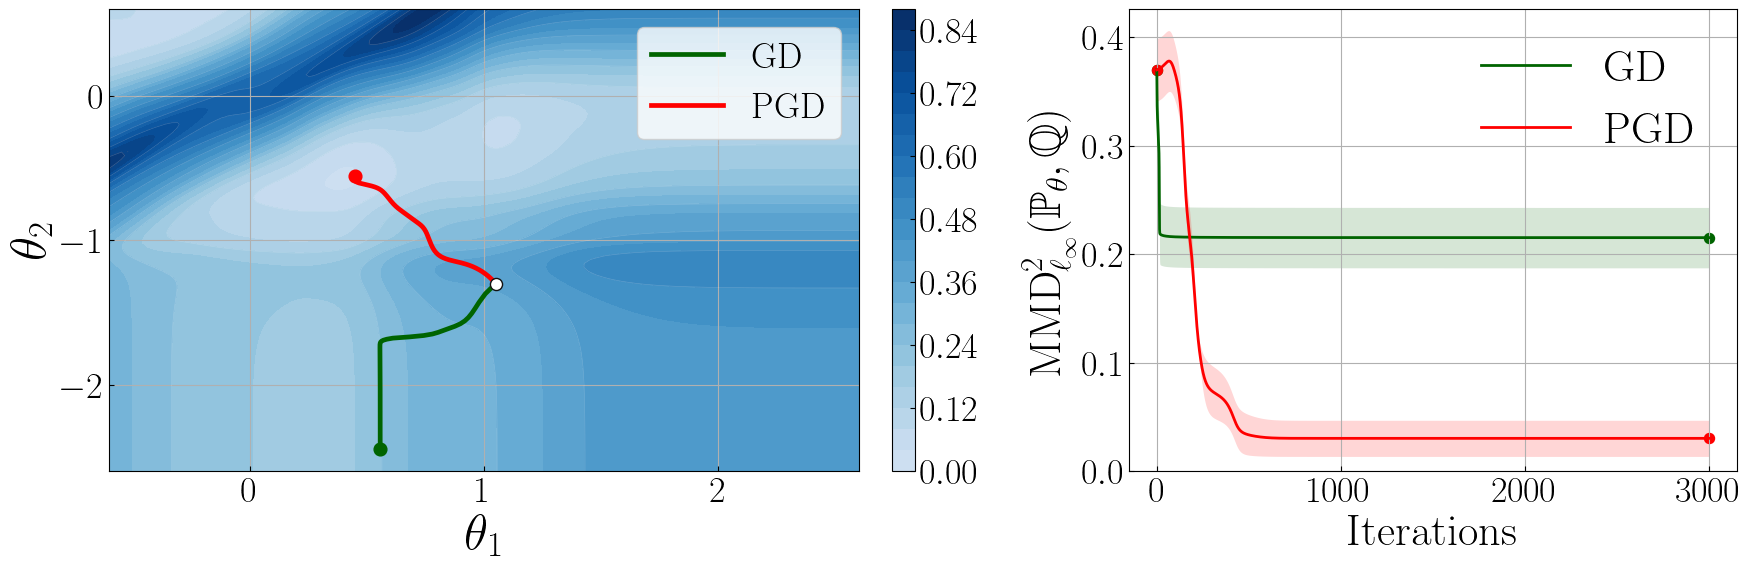

In [3]:
fig, (ax_landscape, ax_history) = plt.subplots(
    1,
    2,
    figsize=(21, 6),
    dpi=100,
    gridspec_kw={'width_ratios': [1.35, 1.0]},
)

contours = ax_landscape.contourf(
    theta1_mesh,
    theta2_mesh,
    landscape_values,
    levels=26,
    cmap=landscape_cmap,
    vmin=0.0,
    vmax=float(np.max(landscape_values)),
)
ax_landscape.contour(
    theta1_mesh,
    theta2_mesh,
    landscape_values,
    levels=12,
    colors='#F8F9FA',
    linewidths=0.45,
    alpha=0.22,
)
ax_landscape.plot(gd_traj[:, 0], gd_traj[:, 1], color='darkgreen', lw=3.4, label='GD')
ax_landscape.plot(pgd_traj[:, 0], pgd_traj[:, 1], color='red', lw=3.4, label='PGD')
ax_landscape.scatter([theta0[0]], [theta0[1]], color='white', edgecolors='#111111', zorder=5, s=76)
ax_landscape.scatter([gd_traj[-1, 0]], [gd_traj[-1, 1]], color='darkgreen', zorder=6, s=84)
ax_landscape.scatter([pgd_traj[-1, 0]], [pgd_traj[-1, 1]], color='red', zorder=6, s=84)
# ax_landscape.text(theta0[0] - 0.12, theta0[1] + 0.08, 'start', color='white', fontsize=15)
# ax_landscape.text(gd_traj[-1, 0] - 0.28, gd_traj[-1, 1] + 0.07, 'standard GD', color='#D0EBFF', fontsize=15)
# ax_landscape.text(pgd_traj[-1, 0] - 0.38, pgd_traj[-1, 1] - 0.10, 'adaptive PGD', color='#D3F9D8', fontsize=15)
ax_landscape.set_xlim(theta_plot_min_x, theta_plot_max_x)
ax_landscape.set_ylim(theta_plot_min_y, theta_plot_max_y)
ax_landscape.set_xlabel(r'$\theta_1$', fontsize=36)
ax_landscape.set_ylabel(r'$\theta_2$', fontsize=36)
ax_landscape.tick_params(axis='both', labelsize=26)
ax_landscape.legend(loc='upper right', fontsize=26, frameon=True)
colorbar = fig.colorbar(contours, ax=ax_landscape, fraction=0.046, pad=0.04)
colorbar.ax.tick_params(labelsize=26)

steps = np.arange(n_steps + 1)
ax_history.plot(steps, objective_gd, color='darkgreen', label='GD')
ax_history.fill_between(
    steps,
    objective_gd - objective_gd_std / 2,
    objective_gd + objective_gd_std / 2,
    color='darkgreen',
    alpha=0.16,
    linewidth=0,
)
ax_history.plot(steps, objective_pgd, color='red', label='PGD')
ax_history.fill_between(
    steps,
    objective_pgd - objective_pgd_std / 2, 
    objective_pgd + objective_pgd_std / 2,
    color='red',
    alpha=0.16,
    linewidth=0,
)
ax_history.scatter([0, n_steps], [objective_gd[0], objective_gd[-1]], color='darkgreen', s=52)
ax_history.scatter([0, n_steps], [objective_pgd[0], objective_pgd[-1]], color='red', s=52)
ax_history.set_xlabel('Iterations', fontsize=32)
ax_history.set_ylabel(r'$\mathrm{MMD}^2_{\ell_\infty}(\mathbb{P}_\theta, \mathbb{Q})$', fontsize=32)
ax_history.set_ylim(bottom=0.0)
ax_history.tick_params(axis='both', labelsize=26)
ax_history.legend(loc='upper right', fontsize=32)

fig.subplots_adjust(wspace=0.28)

plt.savefig('./figures/mmd_nonconvex_example.pdf', bbox_inches='tight')
plt.show()


## Interpretation

The printed midpoint gap certifies non-convexity on a concrete two-parameter slice of the neural-network landscape. In this model, the left panel is a genuine landscape over the two neuron weights $(\theta_1,\theta_2)$ rather than over an affine Gaussian proxy.

The initialization and step sizes are selected from a small candidate set to expose a regime where standard GD and adaptive projected GD behave differently. The key point is that the projected update follows the particle-space witness direction at the adaptive scale $\ell_t$ and can therefore move through the neuron-weight landscape in a way that plain parameter-space GD at the fixed evaluation scale does not.